# Week 3 — Regression Models: House Prices

## Objective
Use the Kaggle House Prices dataset to build and compare multiple supervised regression models.

### Models
- Linear Regression
- Ridge Regression
- Lasso Regression
- Elastic Net
- KNN Regressor
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- Support Vector Regression (SVR)

### Evaluation
MAE, MSE, RMSE, and R².

## 1. Import Libraries

Kaggle source:
https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

Download `train.csv` and place it beside this notebook.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

## 2. Load Dataset

In [4]:
df = pd.read_csv("train.csv")

print("Shape:", df.shape)
df.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Explore the Dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nTarget statistics:")
display(df["SalePrice"].describe())

Missing values:


,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81



Target statistics:


,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


## 4. Explore the Target

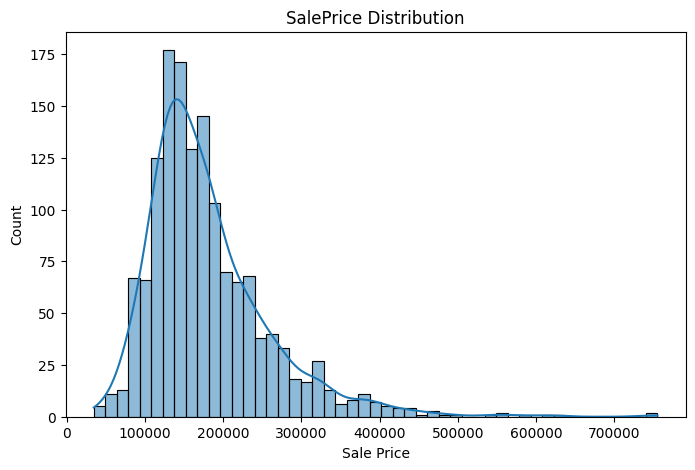

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df["SalePrice"], kde=True)
plt.title("SalePrice Distribution")
plt.xlabel("Sale Price")
plt.show()

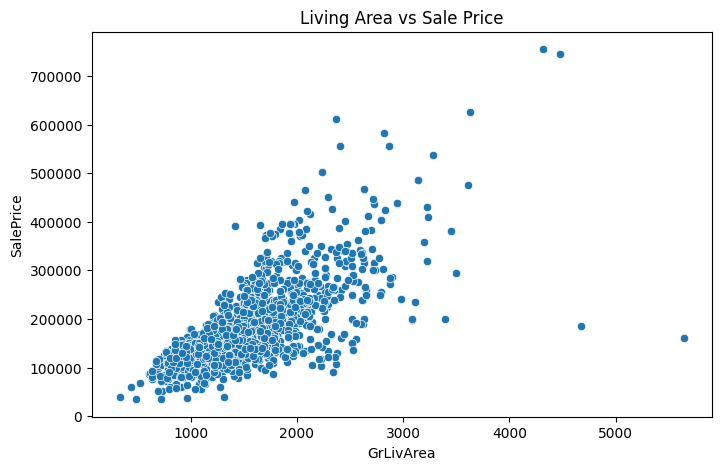

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="GrLivArea", y="SalePrice")
plt.title("Living Area vs Sale Price")
plt.show()

## 5. Feature Selection

For a manageable Week 3 implementation, we use selected numeric and categorical features.

In [9]:
selected_features = [
    "OverallQual", "GrLivArea", "GarageCars", "GarageArea",
    "TotalBsmtSF", "1stFlrSF", "FullBath", "TotRmsAbvGrd",
    "YearBuilt", "YearRemodAdd", "Neighborhood", "KitchenQual",
    "GarageType", "BsmtQual"
]

selected_features = [c for c in selected_features if c in df.columns]

X = df[selected_features].copy()
y = df["SalePrice"].copy()

print("Features:", selected_features)
print("X shape:", X.shape)

Features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd', 'Neighborhood', 'KitchenQual', 'GarageType', 'BsmtQual']
X shape: (1460, 14)


## 6. Train/Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 1168
Testing rows: 292


## 7. Preprocessing

Numerical features are median-imputed and standardized.
Categorical features are imputed and one-hot encoded.

Scaling is particularly important for Linear/Ridge/Lasso/Elastic Net, KNN, and SVR.

In [11]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']
Categorical: ['Neighborhood', 'KitchenQual', 'GarageType', 'BsmtQual']


## 8. Define Regression Models

In [12]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=10.0),
    "Lasso": Lasso(alpha=0.0005, max_iter=10000),
    "Elastic Net": ElasticNet(alpha=0.0005, l1_ratio=0.5, max_iter=10000),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=7),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.03, max_depth=3, random_state=42
    ),
    "SVR": SVR(C=100, epsilon=0.1, kernel="rbf")
}

## 9. Train and Compare Models

In [13]:
results = []
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2_score(y_test, y_pred)
    })
    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df.round(2)

,Model,MAE,MSE,RMSE,R2
7,Gradient Boosting,18006.48,7.889280e+08,28087.86,0.90
6,Random Forest,18399.16,8.396793e+08,28977.22,0.89
3,Elastic Net,20685.33,1.143339e+09,33813.29,0.85
2,Lasso,20705.24,1.143837e+09,33820.65,0.85
0,Linear Regression,20705.25,1.143837e+09,33820.66,0.85
1,Ridge,21016.46,1.169710e+09,34201.02,0.85
4,KNN Regressor,21414.49,1.261011e+09,35510.72,0.84
5,Decision Tree,26447.75,1.959051e+09,44261.17,0.74
8,SVR,50928.51,6.768037e+09,82268.08,0.12


## 10. Visualize Model Comparison

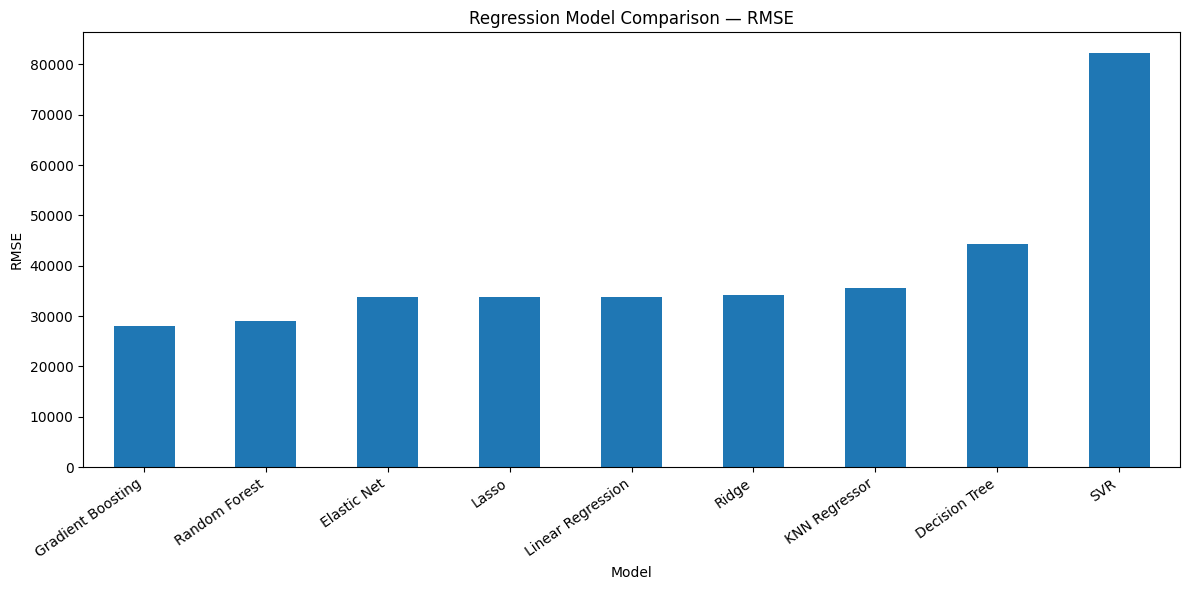

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
results_df.sort_values("RMSE").plot(
    x="Model", y="RMSE", kind="bar", ax=ax, legend=False
)
ax.set_title("Regression Model Comparison — RMSE")
ax.set_ylabel("RMSE")
ax.set_xlabel("Model")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

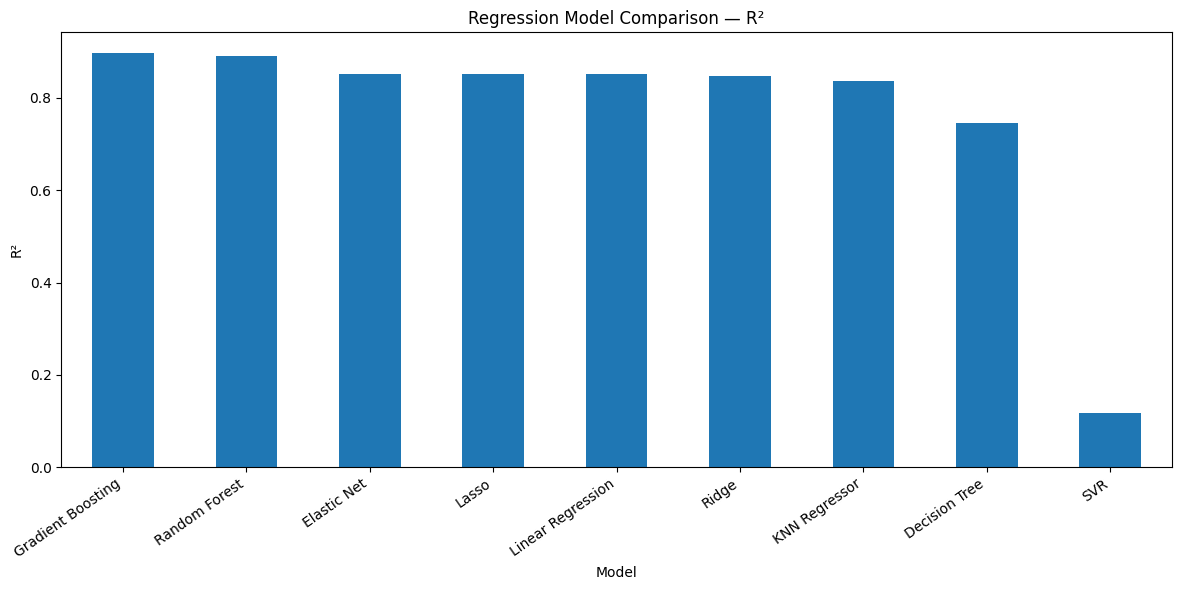

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
results_df.sort_values("R2", ascending=False).plot(
    x="Model", y="R2", kind="bar", ax=ax, legend=False
)
ax.set_title("Regression Model Comparison — R²")
ax.set_ylabel("R²")
ax.set_xlabel("Model")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 11. Actual vs Predicted for the Best Model

Best model by RMSE: Gradient Boosting


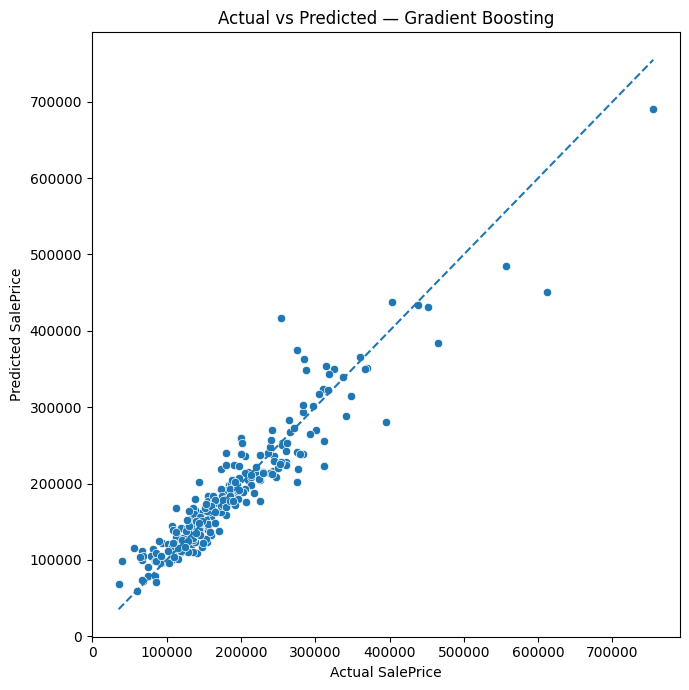

In [16]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_pred = best_model.predict(X_test)

print("Best model by RMSE:", best_model_name)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=best_pred)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title(f"Actual vs Predicted — {best_model_name}")

min_value = min(y_test.min(), best_pred.min())
max_value = max(y_test.max(), best_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.tight_layout()
plt.show()

## 12. Cross-Validation

In [17]:
cv_results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=5, scoring="neg_root_mean_squared_error"
    )
    rmse_scores = -scores

    cv_results.append({
        "Model": name,
        "CV RMSE Mean": rmse_scores.mean(),
        "CV RMSE Std": rmse_scores.std()
    })

cv_df = pd.DataFrame(cv_results).sort_values("CV RMSE Mean")
cv_df.round(2)

,Model,CV RMSE Mean,CV RMSE Std
7,Gradient Boosting,30306.65,4847.21
6,Random Forest,31900.78,5299.62
4,KNN Regressor,32799.68,4913.77
3,Elastic Net,33608.74,6783.08
0,Linear Regression,33626.93,6744.95
2,Lasso,33627.06,6744.87
1,Ridge,33758.50,7315.21
5,Decision Tree,43972.21,5603.43
8,SVR,73302.15,5704.18


## 13. Short Comparison and Conclusion

- **Linear Regression:** strong baseline when relationships are approximately linear.
- **Ridge:** useful with correlated features and regularization.
- **Lasso:** useful when feature selection is helpful.
- **Elastic Net:** combines Ridge and Lasso behavior.
- **KNN:** predicts from nearby examples and is sensitive to scaling.
- **Decision Tree:** captures nonlinear relationships but can overfit.
- **Random Forest:** combines many trees and is robust for tabular data.
- **Gradient Boosting:** sequentially corrects errors and often performs strongly.
- **SVR:** can model nonlinear relationships but usually needs scaling.

### Evaluation
- Lower MAE/MSE/RMSE is better.
- Higher R² is better.
- Cross-validation gives a more reliable comparison than one train/test split alone.

The best algorithm depends on the dataset, preprocessing, hyperparameters, and business objective.